# Contrastive RL — Goal-Conditioned Q(s, a, g) in Four Rooms Grid World

## Problem Description

### The critic
$$f_\theta(s, a, g) = \phi(s, a)^\top \psi(g)$$

where `φ` takes `[onehot(s) ‖ onehot(a)]` and `ψ` takes `onehot(g)`.  
After training with BCE, `sigmoid(f(s,a,g))` ≈ discounted probability of visiting `g` after taking `a` from `s`:

$$Q(s, a, g) \approx (1-\gamma)\sum_{k\ge 1}\gamma^{k-1}\,P(s_{t+k}=g\mid s_t=s, a_t=a)$$

- **Positives** `(s_t, a_t, s_{t+k})` from the same trajectory → label 1  
- **Negatives** same `(s_t, a_t)`, random goal → label 0

Environment Description
---------------------------------------------------

This environment is based on the work of R. Sutton in [Between MDPs and Semi-MDPs: Learning, Planning and Representing Knowledge at Multiple Temporal Scales](http://www.incompleteideas.net/papers/SPS-98.pdf).

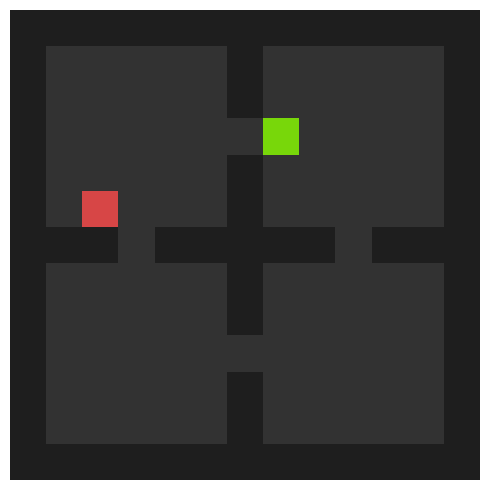


Action Space
-----------------------------------------------------

The action space is the four cardinal directions + noop.
| Num |     Action   |
| --: | -------------|
|   0 |   Move Down  |
|   1 |   Move Right |
|   2 |   Move Up    |
|   3 |   Move Left  |
|   4 |   Noop       |



Observation Space
---------------------------------------------------------------

In order to limit natural function approximation, the observation space is a one-hot encoding of size $\mathcal{S}$. This prevents any natural shared representations between nearby states and forces the network to learn a good representation



In [1]:
# Uncomment to install dependencies if needed
# !pip install jax jaxlib flax optax matplotlib scipy scikit-learn -q


import numpy as np
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import spearmanr

## 1. GridWorld

In [3]:
from gridworld import GridWorld

print('GridWorld class defined.')

GridWorld class defined.


## 2. Create Environment & Visualisation Helper

In [4]:
MAZE = 'fourrooms'

env = GridWorld.create(MAZE, max_steps=200, goal_reward=1.0, step_penalty=0.0)

N_S = env.H * env.W          # total grid cells (including walls), used for one-hot
N_A = 4                       # movement actions: 0=up, 1=right, 2=down, 3=left
SA_DIM = N_S + N_A            # phi input dimension

free_yx_np  = np.array(env.free_yx)                              # (N_free, 2)
free_idxs   = free_yx_np[:, 0] * env.W + free_yx_np[:, 1]      # (N_free,) flat indices
grid_np     = np.array(env.grid)                                  # (H, W) for masking

def yx_to_idx(yx):
    """(y, x) -> flat grid index."""
    return int(yx[0]) * env.W + int(yx[1])

## 3. Data Collection

Roll out a **uniform random policy** (actions 0–3). We collect ~2000 trajectories of the form $(s_1, a_1), \ldots, (s_n, a_n)$.

In [5]:
GAMMA    = 0.95
K_MAX    = 40     # max future lookahead for training triples
N_EP     = 2000   # number of episodes
MAX_STEP = env.max_steps

# ── 1. Collect trajectories as list-of-lists ──────────────────────────────────
def collect_trajectories(n_episodes):
    """
    :returns list of (states, actions) tuples:
      states  : np.ndarray (T+1,) int32  — s_0 … s_T
      actions : np.ndarray (T,)   int32  — a_0 … a_{T-1}
    """
    trajectories = []
    for ep in range(n_episodes):
        _, state = env.reset()
        states  = [yx_to_idx(state.agent_yx)]
        actions = []

        for _ in range(MAX_STEP):
            a = int(np.random.randint(N_A))
            new_state, ts = env.step(state, np.array(a, np.int32))
            actions.append(a)
            states.append(yx_to_idx(new_state.agent_yx))
            state = new_state
            if bool(ts.done):
                break

        trajectories.append((states, actions))

    print(f'Collected {len(trajectories)} trajectories')
    print(f'Mean length: {np.mean([len(a) for _, a in trajectories]):.1f} steps')
    return trajectories


trajectories = collect_trajectories(N_EP)

Collected 2000 trajectories
Mean length: 156.8 steps


In [6]:
def positive_sample(states: np.ndarray, t: int, gamma: float) -> int:
    """
    :param states: trajectory of states
    :param t: index of current state
    :param gamma: discount factor to parametrize geometric distribution
    :returns g: future state drawn according to Geom(1 - \gamma)
    """
    max_k = len(states) - 1 - t
    if max_k <= 0:
        return int(states[-1])
    k = min(np.random.geometric(1 - gamma), max_k)
    return int(states[t + k])


def sample_batch(trajectories, gamma, batch_size=512, neg_ratio=0.5):
    """
    :returns batch of sa, g, labels:
      sa: (batch_size, [one_hot(s), one_hot(a)])
      g: (batch_size, one_hot(g))
      labels: (batch_size,), 0 if goal is negative sample of (s,a) 1 otherwise.
    """
    n_pos = int(batch_size * (1 - neg_ratio))
    n_neg = batch_size - n_pos

    sa_list, g_list, label_list = [], [], []

    for _ in range(n_pos):
        # TO_DO:
        #########################################################################################################
        # Must get (s, a, g^+) tuples, where g is sampled according to successor measure conditioned on (s, a)
        # Optionally can use positive_sample. Recall: first get (s,a) then sample future t ~ Geom(1 - \gamma)
        traj = trajectories[np.random.randint(len(trajectories))]
        states, actions = traj

        t = np.random.randint(0, len(actions))
        s = int(states[t])
        a = int(actions[t])
        g = positive_sample(states, t, gamma)

        sa_list.append((s, a))
        g_list.append(g)

        # END_TO_DO
        #########################################################################################################
        label_list.append(1.0)

    for _ in range(n_neg):
        # TO_DO:
        #########################################################################################################
        # Must get (s, a, g^-) tuples, where g is sampled independently of a.
        # Can sample (s,a) the same. Then sample t uniformly across WHOLE trajectory.
        traj_sa = trajectories[np.random.randint(len(trajectories))]
        states_sa, actions_sa = traj_sa

        t = np.random.randint(0, len(actions_sa))
        s = int(states_sa[t])
        a = int(actions_sa[t])

        traj_g = trajectories[np.random.randint(len(trajectories))]
        states_g, _ = traj_g
        g = int(states_g[np.random.randint(len(states_g))])

        sa_list.append((s, a))
        g_list.append(g)

        # END_TO_DO
        #########################################################################################################
        label_list.append(0.0)

    # ── Encode ────────────────────────────────────────────────────────────────
    sa_enc = np.zeros((batch_size, N_S + N_A), dtype=np.float32)
    g_enc  = np.zeros((batch_size, N_S), dtype=np.float32)
    labels = np.array(label_list, dtype=np.float32)

    for i, ((s, a), g) in enumerate(zip(sa_list, g_list)):
        sa_enc[i, s] = 1.0
        sa_enc[i, N_S + a] = 1.0
        g_enc[i, g] = 1.0

    return sa_enc, g_enc, labels

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:6: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_18047/2576616008.py:6: SyntaxWarning: invalid escape sequence '\g'
  :returns g: future state drawn according to Geom(1 - \gamma)


## 4. Encoding + Flax Model

### Recall

**Encoding** — states and goals are one-hot over all `H×W` grid cells; actions are one-hot over 4.  
`φ` sees the concatenation `[onehot(s) ‖ onehot(a)]`.

**Model** — two MLP encoders with a bilinear dot-product head:
$$f_\theta(s,a,g) = \phi(s,a)^\top\psi(g)$$

In [7]:
from typing import Sequence


def encode_sa(s: jnp.ndarray, a: jnp.ndarray) -> jnp.ndarray:
    """(B,) int32 -> (B, SA_DIM) concatenated one-hot."""
    return jnp.concatenate([
        jax.nn.one_hot(s, N_S),
        jax.nn.one_hot(a, N_A),
    ], axis=-1)

def encode_g(g: jnp.ndarray) -> jnp.ndarray:
    """(B,) int32 -> (B, N_S) one-hot."""
    return jax.nn.one_hot(g, N_S)


class MLP(nn.Module):
    features: Sequence[int]

    @nn.compact
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        for i, feat in enumerate(self.features):
            x = nn.Dense(feat)(x)
            if i < len(self.features) - 1:
                x = nn.LayerNorm()(x)
                x = nn.relu(x)
        return x


class ContrastiveQFunction(nn.Module):
    """
    f(s, a, g) = phi(s, a) . psi(g)

    phi : [onehot(s) || onehot(a)] -> embed_dim
    psi : onehot(g)                -> embed_dim

    Trained with binary BCE:
      Positive (s_t, a_t, s_{t+k}) same traj -> label 1
      Negative (s_t, a_t, s_rand)  random g  -> label 0
    """
    hidden:    int = 256
    embed_dim: int = 64

    @nn.compact
    def __call__(self, sa: jnp.ndarray, g: jnp.ndarray) -> jnp.ndarray:
        """Raw logit scores, shape (B,)."""
        phi = MLP([self.hidden, self.hidden, self.embed_dim])(sa)
        psi = MLP([self.hidden, self.hidden, self.embed_dim])(g)
        return jnp.sum(phi * psi, axis=-1)


# ── Initialise params ─────────────────────────────────────────────────────────
model = ContrastiveQFunction(hidden=256, embed_dim=64)

KEY = jax.random.PRNGKey(42)
KEY, init_key = jax.random.split(KEY)
dummy_sa = jnp.zeros((1, SA_DIM))
dummy_g  = jnp.zeros((1, N_S))
params   = model.init(init_key, dummy_sa, dummy_g)

## 5. Training with Binary BCE Loss

Now you must train the critic to optimize the following binary cross entropy loss. Hint: `optax.sigmoid_binary_cross_entropy`.
$$\mathcal{L}(\theta) = -\mathbb{E}_{+}[\log\sigma(f(s,a,g^+))] - \mathbb{E}_{-}[\log(1-\sigma(f(s,a,g^-)))]$$
**Recall**: Accuracy may not go up because the closer the two distributions are the better!

**NOTE**: if training is too slow. it is unlikely you need to train for this many steps / batch size. if you still want to, it should be considerably faster using TPU instance on Colab.

In [8]:
LR = 3e-4
optimizer = optax.adam(LR)
opt_state = optimizer.init(params)


def train(
    model,
    params,
    optimizer,
    opt_state,
    trajectories,
    gamma,
    n_steps     = 30_000,
    batch_size  = 1024,
    log_every   = 3_000,
):
    @jax.jit
    def train_step(params, opt_state, sa, g, labels):
        # TO_DO:
        #########################################################################################################
        # Apply BCE loss on positive / negatives and update params

        def loss_fn(params):
            logits = model.apply(params, sa, g).reshape(-1)
            return optax.sigmoid_binary_cross_entropy(logits, labels).mean()

        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_o = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)

        # END_TO_DO
        #########################################################################################################
        acc = jnp.mean((model.apply(new_params, sa, g) > 0) == (labels > 0.5))
        return new_params, new_o, loss, acc

    history = []
    for step in range(1, n_steps + 1):
        sa_np, g_np, labels_np = sample_batch(
            trajectories, gamma, batch_size
        )
        sa = jnp.array(sa_np)
        g = jnp.array(g_np)
        labels = jnp.array(labels_np)

        params, opt_state, loss, acc = train_step(params, opt_state, sa, g, labels)
        history.append({'step': step, 'loss': float(loss), 'acc': float(acc)})

        if step % log_every == 0:
            print(f'step {step:>6d}  |  loss {loss:.4f}  |  acc {acc:.3f}')

    return params, opt_state, history


params, opt_state, history = train(
    model, params, optimizer, opt_state,
    trajectories, GAMMA,
)

step   3000  |  loss 0.4159  |  acc 0.821
step   6000  |  loss 0.4029  |  acc 0.833
step   9000  |  loss 0.4016  |  acc 0.818
step  12000  |  loss 0.4218  |  acc 0.817
step  15000  |  loss 0.4025  |  acc 0.833
step  18000  |  loss 0.3856  |  acc 0.844
step  21000  |  loss 0.4168  |  acc 0.821
step  24000  |  loss 0.3975  |  acc 0.828
step  27000  |  loss 0.3649  |  acc 0.847
step  30000  |  loss 0.4110  |  acc 0.815


## 6. Q(s, a, g*) Per Action

Fix a goal $g*$ and plot $Q(s, a, g*)$ for each of the 4 actions. Each column is the $Q$-value for each of the states with that action.

The key insight: by conditioning on $a$, we get **four distinct reachability landscapes** per goal. The action that is most valuable at each state points toward the goal. To see the difference, look at the junction points. Moving left should have higher $Q$ value in the top junction and moving up in the bottom left junction.

In [9]:
ACTION_NAMES  = ['Up', 'Right', 'Down', 'Left']
ACTION_ARROWS = ['\u2191', '\u2192', '\u2193', '\u2190']



def plot_grid(env, ax, values=None, arrows=None, goal_yx=None,
              title='', cmap='viridis', vmin=None, vmax=None):
    """
    Render the grid world.
      :param values: flat float array len(H*W) — heatmap overlay
      :param arrows: flat int   array len(H*W) — best action per free cell
      :param goal_yx: (y, x) tuple
    """
    H, W = env.H, env.W
    wall_mask = grid_np == 1

    base = np.ones((H, W, 3)) * 0.92
    base[wall_mask] = [0.18, 0.18, 0.18]
    ax.imshow(base, origin='upper', interpolation='nearest', zorder=0)

    if values is not None:
        v = np.array(values, dtype=float).reshape(H, W)
        masked = np.ma.masked_where(wall_mask, v)
        _vmin = vmin if vmin is not None else float(np.nanmin(v[~wall_mask]))
        _vmax = vmax if vmax is not None else float(np.nanmax(v[~wall_mask]))
        hm = ax.imshow(masked, cmap=cmap, origin='upper', interpolation='nearest',
                       alpha=0.88, zorder=1, vmin=_vmin, vmax=_vmax)
        plt.colorbar(hm, ax=ax, fraction=0.046, pad=0.04)

    if arrows is not None:
        for r in range(H):
            for c in range(W):
                if not wall_mask[r, c]:
                    a = int(arrows[r * W + c])
                    ax.text(c, r, ACTION_ARROWS[a], ha='center', va='center',
                            fontsize=7, color='white', fontweight='bold', zorder=4)

    if goal_yx is not None:
        gy, gx = goal_yx
        ax.scatter(gx, gy, marker='*', s=220, c='red', zorder=5, label='g*')
        ax.legend(fontsize=8, loc='upper right')

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)

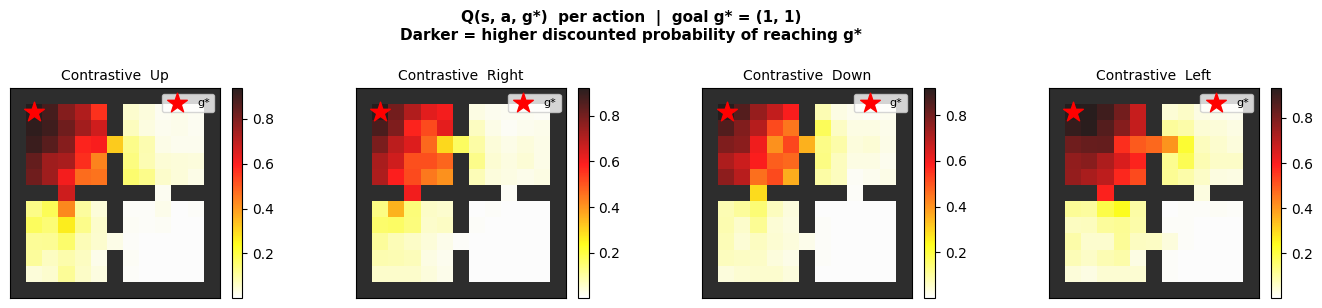

In [10]:
# ── Compute Q(s, a, g*) for all states, given action a and goal g* ────────────
def compute_q_grid(params, action: int, goal_idx: int) -> np.ndarray:
    """
    Returns Q(s, a, g*) for every grid cell.
    Shape (H*W,). Wall cells set to NaN.
    """
    all_s = jnp.arange(N_S, dtype=jnp.int32)
    a_vec = jnp.full((N_S,), action, dtype=jnp.int32)
    g_vec = jnp.full((N_S,), goal_idx, dtype=jnp.int32)
    sa    = encode_sa(all_s, a_vec)
    g_enc = encode_g(g_vec)
    q     = jax.nn.sigmoid(model.apply(params, sa, g_enc))
    q_np  = np.array(q)
    for r in range(env.H):
        for c in range(env.W):
            if grid_np[r, c] == 1:
                q_np[r * env.W + c] = np.nan
    return q_np


# ── Plot for a chosen goal ────────────────────────────────────────────────────
GOAL_YX  = (1, 1)      # top-left room
GOAL_IDX = yx_to_idx(GOAL_YX)

q_learned = [compute_q_grid(params, a, GOAL_IDX) for a in range(N_A)]

fig, axes = plt.subplots(1, N_A, figsize=(14, 3))
for a in range(N_A):
    plot_grid(env, axes[a], values=q_learned[a], goal_yx=GOAL_YX,
              title=f'Contrastive  {ACTION_NAMES[a]}', cmap='hot_r')

plt.suptitle(f'Q(s, a, g*)  per action  |  goal g* = {GOAL_YX}\n'
             'Darker = higher discounted probability of reaching g*',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout();
plt.show()

## 7. Greedy Policy:  π*(s | g) = argmax_a Q(s, a, g)

Since we have a full Q-function we get a goal-conditioned policy for free — no actor training needed.

/tmp/ipykernel_18047/96589647.py:16: RuntimeWarning: All-NaN slice encountered
  v_l  = np.nanmax(np.stack(ql), axis=0)


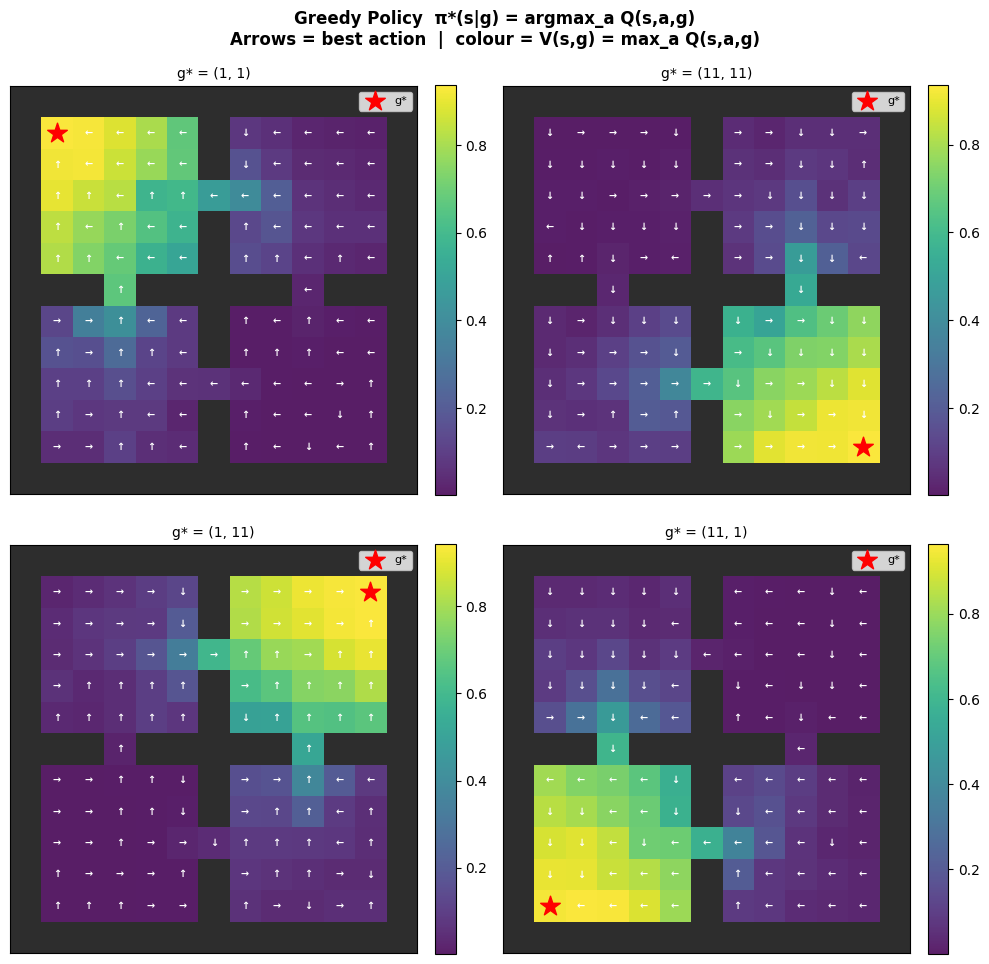

In [11]:
def extract_policy(q_per_action):
    """:param q_per_action: list of N_A arrays of shape (H*W,). Returns argmax (H*W,)."""
    stacked = np.stack(q_per_action, axis=0)         # (N_A, H*W)
    stacked = np.where(np.isnan(stacked), -np.inf, stacked)
    return np.argmax(stacked, axis=0).astype(int)     # (H*W,)


goals_to_show = [(1, 1), (11, 11), (1, 11), (11, 1)]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, g_yx in zip(axes.flat, goals_to_show):
    g_idx = yx_to_idx(g_yx)
    ql   = [compute_q_grid(params, a, g_idx) for a in range(N_A)]
    pi_l = extract_policy(ql)
    v_l  = np.nanmax(np.stack(ql), axis=0)
    plot_grid(env, ax, values=v_l, arrows=pi_l, goal_yx=g_yx,
              title=f'g* = {g_yx}', cmap='viridis')

plt.suptitle('Greedy Policy  π*(s|g) = argmax_a Q(s,a,g)\n'
             'Arrows = best action  |  colour = V(s,g) = max_a Q(s,a,g)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Q-function as temporal distance.

We compare the learned $V(s, g*) = \max_a Q(s,a,g*)$ against the **BFS shortest-path distance** to $g*$. An alternative interpretation for $V(s, g)$ is that it encodes *temporal distance* i.e. inversely proportional to the number of steps required to reach one state from another. To see this, we can compare the [spearman coefficient](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient) with the true temporal distance.

Intuitively, the spearman coefficient measures the correlation between the rankings of the two functions. If $s_1$ is closer to $g_1$ than $s_2$, then we should have that $V(s_1, g_1) \geq V(s_2, g_1)$.

To receive full credit, you need a spearman coefficient > 0.8.

/tmp/ipykernel_18047/32885772.py:11: RuntimeWarning: All-NaN slice encountered
  v_learned = np.nanmax(np.stack(ql_for_goal), axis=0)


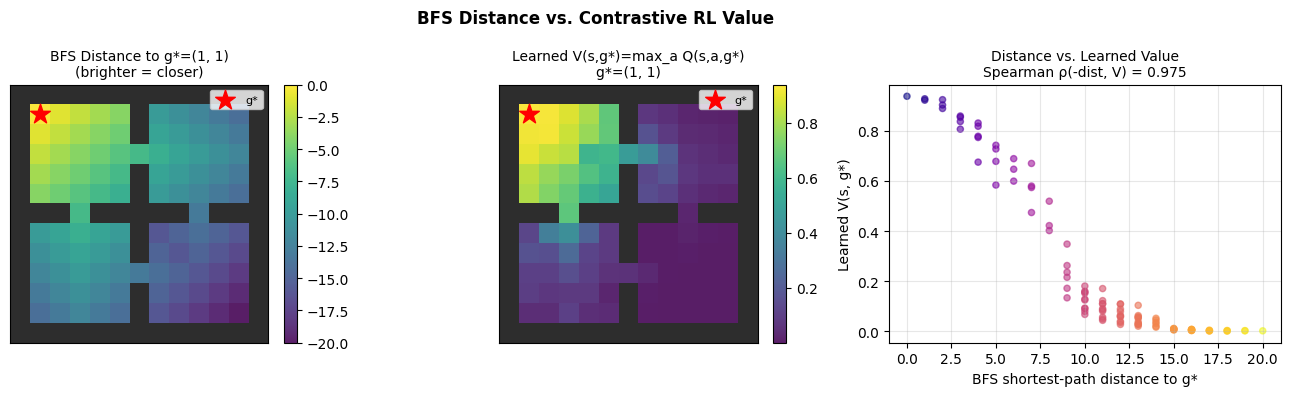

Spearman ρ(−distance, V): 0.9746  (closer to 1 = better)


In [12]:
GOAL_YX  = (1, 1)
GOAL_IDX = yx_to_idx(GOAL_YX)

dist_grid = env.get_dist(jnp.array(GOAL_YX, dtype=jnp.int32))   # (H, W) shortest-path dist
dist_flat = dist_grid.flatten().astype(float)
dist_flat[dist_flat < 0] = np.nan    # walls / unreachable

ql_for_goal = [compute_q_grid(params, a, GOAL_IDX) for a in range(N_A)]

with np.errstate(all='ignore'):
    v_learned = np.nanmax(np.stack(ql_for_goal), axis=0)

# Scatter: BFS distance vs. learned V(s,g*)
mask   = ~np.isnan(dist_flat) & ~np.isnan(v_learned)
d_vals = dist_flat[mask]
v_vals = v_learned[mask]
rho_d, _ = spearmanr(-d_vals, v_vals)   # expect negative: farther = lower Q

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# BFS distance heatmap
plot_grid(env, axes[0], values=-dist_flat, goal_yx=GOAL_YX,
          title=f'BFS Distance to g*={GOAL_YX}\n(brighter = closer)', cmap='viridis')

# Learned V heatmap
plot_grid(env, axes[1], values=v_learned, goal_yx=GOAL_YX,
          title=f'Learned V(s,g*)=max_a Q(s,a,g*)\ng*={GOAL_YX}', cmap='viridis')

axes[2].scatter(d_vals, v_vals, alpha=0.6, s=20, c=d_vals, cmap='plasma')
axes[2].set_xlabel('BFS shortest-path distance to g*', fontsize=10)
axes[2].set_ylabel('Learned V(s, g*)', fontsize=10)
axes[2].set_title(f'Distance vs. Learned Value\nSpearman ρ(-dist, V) = {rho_d:.3f}', fontsize=10)
axes[2].grid(alpha=0.3)

plt.suptitle('BFS Distance vs. Contrastive RL Value', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Spearman ρ(−distance, V): {rho_d:.4f}  (closer to 1 = better)')

# 9. Save Model Weights

In [13]:
import numpy as np
from flax.traverse_util import flatten_dict, unflatten_dict

# Save
flat = flatten_dict(params, sep='/')
np.savez('params.npz', **flat)